In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded CSV file to analyze its structure and contents.
data = pd.read_csv('mjerenja_15_12.csv')

# Display the first few rows and column names for inspection.
data.head(), data.columns

# Split the single column into two separate columns based on the semicolon delimiter.
data_split = data.iloc[:, 0].str.split(';', expand=True)
data_split.columns = ['V1', 'V2']

# Convert the columns to numeric values for further analysis.
data_split['V1'] = pd.to_numeric(data_split['V1'].str.strip())
data_split['V2'] = pd.to_numeric(data_split['V2'].str.strip())

# Display the first few rows of the processed data.
data_split.head()

,V1,V2
0,2.08,1.46
1,2.34,0.41
2,2.71,1.17
3,2.42,0.73
4,2.53,0.97


Proces mjerenja:

Voltage V1: "napon sa 310nm"	Voltage V2: "napon sa 320nm"\
-tako 30-ak sekundi\
-zamjena filtera\
Voltage V1: "smeće"	Voltage V2: "smeće"\
-dok se ne stabilizira\
Voltage V1: "napon sa 320nm"	Voltage V2: "napon sa 310nm"\
-tako 30-ak sekundi\
-zamjena filtera\
Voltage V1: "smeće"	Voltage V2: "smeće"\
-dok se ne stabilizira\

i tako u loop

Što će reći da bi trebali imati barem 10-15 sekundi (znači 10-15 vrijednosti ako se čitalo svake sekunde) mjerenja gdje je odstupanje manje od 5% srednje vrijednosti da bi to mjerenje bilo razumno uzeti u obzir.

In [2]:
# Define a function to find 10 consecutive values meeting the criteria for mean and std deviation
def find_consecutive_with_criteria(data, column_name, threshold=0.05, group_size=10):
    for i in range(len(data) - group_size + 1):
        group = data[column_name].iloc[i:i + group_size]
        mean = group.mean()
        std = group.std()
        if std / mean < threshold:
            return i, group.tolist(), mean, std  # Return index, values, mean, and std deviation
    return None

# Check for V1
result_v1 = find_consecutive_with_criteria(data_split, 'V1')

# Check for V2
result_v2 = find_consecutive_with_criteria(data_split, 'V2')

result_v1, result_v2

((114,
  [2.4, 2.68, 2.7, 2.35, 2.44, 2.41, 2.47, 2.49, 2.48, 2.41],
  2.483,
  0.11700427342623008),
 None)

In [3]:
# Define a function to find all sequences of 10 consecutive values meeting the criteria
def find_all_consecutive_with_criteria(data, column_name, threshold=0.05, group_size=10):
    results = []
    for i in range(len(data) - group_size + 1):
        group = data[column_name].iloc[i:i + group_size]
        mean = group.mean()
        std = group.std()
        if std / mean < threshold:
            results.append({
                "start_index": i,
               #"values": group.tolist(),
                "mean": mean,
                "std_dev": std,
                "std_to_mean_ratio": std / mean
            })
    return results

# Check for all sequences in V1
results_v1_5 = find_all_consecutive_with_criteria(data_split, 'V1')

# Check for all sequences in V2
results_v2_5 = find_all_consecutive_with_criteria(data_split, 'V2')

len(results_v1_5), len(results_v2_5), results_v1_5, results_v2_5  # Display count and first 3 results

(94,
 0,
 [{'start_index': 114,
   'mean': 2.483,
   'std_dev': 0.11700427342623008,
   'std_to_mean_ratio': 0.04712213992196137},
  {'start_index': 115,
   'mean': 2.479,
   'std_dev': 0.1207798732313368,
   'std_to_mean_ratio': 0.048721207434988624},
  {'start_index': 186,
   'mean': 2.478,
   'std_dev': 0.12072006185109964,
   'std_to_mean_ratio': 0.048716731981880396},
  {'start_index': 187,
   'mean': 2.438,
   'std_dev': 0.09975525605756876,
   'std_to_mean_ratio': 0.04091684005642689},
  {'start_index': 188,
   'mean': 2.4349999999999996,
   'std_dev': 0.09709674442419673,
   'std_to_mean_ratio': 0.03987545972246273},
  {'start_index': 189,
   'mean': 2.457,
   'std_dev': 0.11421714212654574,
   'std_to_mean_ratio': 0.04648642333192745},
  {'start_index': 190,
   'mean': 2.475,
   'std_dev': 0.11664285471281789,
   'std_to_mean_ratio': 0.047128426146593086},
  {'start_index': 191,
   'mean': 2.467,
   'std_dev': 0.11747813035246646,
   'std_to_mean_ratio': 0.0476198339491149},
 

(array([187., 303., 432., 474., 519., 438., 301., 171.,  74.,  27.]),
 array([0.   , 0.257, 0.514, 0.771, 1.028, 1.285, 1.542, 1.799, 2.056,
        2.313, 2.57 ]),
 <BarContainer object of 10 artists>)

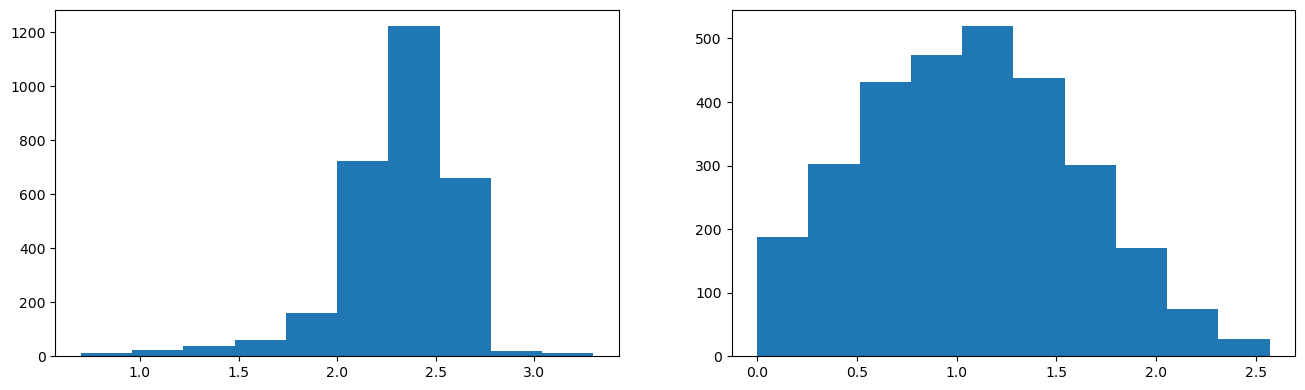

In [7]:
fig, ax = plt.subplots(1,2,figsize=(16,4.5))

ax[0].hist(data_split['V1'])
ax[1].hist(data_split['V2'])